In [1]:
from pathlib import Path
from typing import Union, Optional
import pandas as pd
import numpy as np
import logging
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

In [31]:
# Use pathlib for robust path handling
BASE_DIR = Path.cwd().parent 
PROCESSED_DATA_DIR = BASE_DIR / "data_processed"
CONFIG_DIR = BASE_DIR / "config"
BRFSS_ZIP_FILE = PROCESSED_DATA_DIR / "BRFSS_2015_2024.zip"
BRFSS_CLEAN_ZIP_FILE = PROCESSED_DATA_DIR / "BRFSS_2015_2024_cleaned.zip"
RECODE_MAP_FILE = CONFIG_DIR / "recode_mappings.json"
BRFSS_RECODED_ZIP_FILE = PROCESSED_DATA_DIR / "BRFSS_2015_2024_recoded.zip"
RECODED_CONFIG_FILE = CONFIG_DIR / "VALUE_RECODED_TEXT_MAP.json"

# Ensure directories exist
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
def read_zipped_csv(
    zip_path: Union[str, Path],
    **read_csv_kwargs
) -> pd.DataFrame:
    """
    Read a single-CSV .zip file into a pandas DataFrame.

    Parameters
    ----------
    zip_path : str or Path
        Path to the .zip file (containing exactly one CSV, or a CSV
        with the same name as the zip).
    **read_csv_kwargs :
        Any extra keyword args passed through to pandas.read_csv
        (e.g. sep, dtype, parse_dates).

    Returns
    -------
    pd.DataFrame
    """
    zip_path = Path(zip_path)
    # For a single CSV in the zip, this is enough:
    return pd.read_csv(zip_path, compression="zip", **read_csv_kwargs)

In [4]:
def write_df_to_zipped_csv(
    df: pd.DataFrame,
    zip_path: Union[str, Path],
    csv_name: str | None = None,
    **to_csv_kwargs,
) -> None:
    """
    Write a DataFrame to a CSV stored inside a .zip file.

    Parameters
    ----------
    df : pd.DataFrame
        Data to write.
    zip_path : str or Path
        Path to the .zip file to create, e.g. 'data.zip'.
    csv_name : str, optional
        Name of the CSV file inside the zip, e.g. 'data.csv'.
        If None, uses the zip file stem with '.csv'.
    **to_csv_kwargs :
        Extra keyword args passed to DataFrame.to_csv
        (e.g. index=False, sep=',', encoding='utf-8').
    """
    zip_path = Path(zip_path)
    if csv_name is None:
        csv_name = zip_path.stem + ".csv"

    compression_opts = {
        "method": "zip",
        "archive_name": csv_name,
    }

    df.to_csv(
        zip_path,
        header=True,
        compression=compression_opts,
        **to_csv_kwargs,
    )

In [5]:
# Load the BRFSS data
df = read_zipped_csv(BRFSS_ZIP_FILE)
logging.info(f"Initial data loaded with {df.shape[0]} rows. and columns: {df.shape[1]}")

2026-02-04 10:55:28 - INFO - Initial data loaded with 4410255 rows. and columns: 19


In [6]:
def print_unique_values(data, columnName):
    unique_column_values = data[columnName].unique()
    if pd.api.types.is_numeric_dtype(unique_column_values):
        unique_column_values = np.sort(unique_column_values)
    column_datatype = data[columnName].dtype
    num_unique_column_values = len(unique_column_values)
    print(f'{num_unique_column_values} Unique values in column {columnName} of type {column_datatype}: {unique_column_values}')

# For each column, print unique values
for col in df.columns:
    print_unique_values(df, col)

10 Unique values in column YEAR of type int64: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
7 Unique values in column DIABETES of type float64: [ 1.  2.  3.  4.  7.  9. nan]
14 Unique values in column AGE_CATEGORIES of type float64: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]
4 Unique values in column SEX of type float64: [1. 2. 7. 9.]
10 Unique values in column RACE of type float64: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. nan]
7 Unique values in column INCOME of type float64: [ 1.  2.  3.  4.  5.  9. nan]
5 Unique values in column EDUCATION_LEVEL of type float64: [1. 2. 3. 4. 9.]
10 Unique values in column EMPLOYMENT of type float64: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. nan]
8 Unique values in column MARITAL_STATUS of type float64: [ 1.  2.  3.  4.  5.  6.  9. nan]
3 Unique values in column HEALTH_CARE_COVERAGE of type float64: [1. 2. 9.]
5 Unique values in column BMICAT of type float64: [ 1.  2.  3.  4. nan]
3 Unique values in column HEART_ATTACK of type float64: [ 

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410255 entries, 0 to 4410254
Data columns (total 19 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   YEAR                       int64  
 1   DIABETES                   float64
 2   AGE_CATEGORIES             float64
 3   SEX                        float64
 4   RACE                       float64
 5   INCOME                     float64
 6   EDUCATION_LEVEL            float64
 7   EMPLOYMENT                 float64
 8   MARITAL_STATUS             float64
 9   HEALTH_CARE_COVERAGE       float64
 10  BMICAT                     float64
 11  HEART_ATTACK               float64
 12  STROKE                     float64
 13  EXERCISE                   float64
 14  SMOKER                     float64
 15  HEAVY_ALCOHOL_CONSUMPTION  float64
 16  HEALTH_STATUS              float64
 17  POOR_PHYSICAL_HEALTH_DAYS  float64
 18  POOR_MENTAL_HEALTH_DAYS    float64
dtypes: float64(18), int64(1)
memory usage: 639

In [8]:
def recode_column(df, col_name, old_values, new_values):
    if len(old_values) != len(new_values):
        raise ValueError("old_values and new_values must have same length")
    mapping = dict(zip(old_values, new_values))
    df[col_name] = df[col_name].replace(mapping)
    return df

def apply_recode_map(df, map_file=RECODE_MAP_FILE):
    """Apply recoding and missing value handling based on a JSON config file."""
    with open(map_file, 'r') as f:
        recode_map = json.load(f)
    
    for col_name, mapping in recode_map.items():
        if col_name not in df.columns:
            continue

        if mapping.get('multi_step'):
            # Handle grouped (e.g. SMOKER)
            no_codes = mapping['no_codes']
            yes_codes = mapping['yes_codes']

            # if is_numeric:
            #     no_codes = [float(x) for x in no_codes]
            #     yes_codes = [float(x) for x in yes_codes]

            df.loc[df[col_name].isin(no_codes), col_name] = 0
            df.loc[df[col_name].isin(yes_codes), col_name] = 1
        else:
            # Direct 1:1
            old_vals = mapping['old_values']
            new_vals = mapping['new_values']
            df = recode_column(df, col_name, old_vals, new_vals)
    
        missing_vals = mapping.get('missing_values', [])
        if missing_vals:
            # if is_numeric:
            #     # Convert config strings ("77", "99") to floats (77.0, 99.0)
            #     missing_vals = [float(x) for x in missing_vals]
            
            # Replace only in this specific column
            df[col_name] = df[col_name].replace(missing_vals, np.nan)
    
    return df

# Apply to your DataFrame
df = apply_recode_map(df)

In [9]:
# For each column, print unique values
for col in df.columns:
    print_unique_values(df, col)

10 Unique values in column YEAR of type int64: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
3 Unique values in column DIABETES of type float64: [ 0.  1. nan]
14 Unique values in column AGE_CATEGORIES of type float64: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. nan]
3 Unique values in column SEX of type float64: [ 0.  1. nan]
9 Unique values in column RACE of type float64: [ 1.  2.  3.  4.  5.  6.  7.  8. nan]
6 Unique values in column INCOME of type float64: [ 0.  1.  2.  3.  4. nan]
5 Unique values in column EDUCATION_LEVEL of type float64: [ 0.  1.  2.  3. nan]
9 Unique values in column EMPLOYMENT of type float64: [ 0.  1.  2.  3.  4.  5.  6.  7. nan]
7 Unique values in column MARITAL_STATUS of type float64: [ 0.  1.  2.  3.  4.  5. nan]
3 Unique values in column HEALTH_CARE_COVERAGE of type float64: [ 0.  1. nan]
5 Unique values in column BMICAT of type float64: [ 0.  1.  2.  3. nan]
3 Unique values in column HEART_ATTACK of type float64: [ 0.  1. nan]
3 Unique value

In [10]:
# Drop rows where DIABETES is NaN
logging.info("Dropping rows with missing DIABETES values.")
initial_row_count = df.shape[0]
df = df.dropna(subset=['DIABETES'])
logging.info(f"Data after dropping missing DIABETES has {df.shape[0]} rows (dropped {initial_row_count - df.shape[0]} rows).")
logging.info("Data description:\n")
df.describe().T

2026-02-04 11:05:22 - INFO - Dropping rows with missing DIABETES values.
2026-02-04 11:05:23 - INFO - Data after dropping missing DIABETES has 4401191 rows (dropped 9064 rows).
2026-02-04 11:05:23 - INFO - Data description:



,count,mean,std,min,25%,50%,75%,max
YEAR,4401191.0,2019.469706,2.905856,2015.0,2017.0,2019.0,2022.0,2024.0
DIABETES,4401191.0,0.144087,0.351178,0.0,0.0,0.0,0.0,1.0
AGE_CATEGORIES,4326572.0,6.663148,3.555984,0.0,4.0,7.0,10.0,12.0
SEX,4399810.0,0.453882,0.497869,0.0,0.0,0.0,1.0,1.0
RACE,4307831.0,2.005677,2.200405,1.0,1.0,1.0,1.0,8.0
INCOME,3470388.0,2.873909,1.391763,0.0,2.0,4.0,4.0,4.0
EDUCATION_LEVEL,4382039.0,1.993047,0.964000,0.0,1.0,2.0,3.0,3.0
EMPLOYMENT,4336807.0,5.402433,1.816464,0.0,5.0,6.0,7.0,7.0
MARITAL_STATUS,4364056.0,3.384585,1.932794,0.0,2.0,5.0,5.0,5.0
HEALTH_CARE_COVERAGE,2710153.0,0.102934,0.303873,0.0,0.0,0.0,0.0,1.0


In [11]:
# Impute missing data for each column as per strategy
for col_name in df.columns:
    num_missing = df[col_name].isna().sum()
    if num_missing > 0:
        if pd.api.types.is_numeric_dtype(df[col_name]):
            median_value = df[col_name].median()
            df[col_name].fillna(median_value, inplace=True)
            logging.info(f"Imputed {num_missing} missing values in numeric column '{col_name}' with median value {median_value}.")
        else:
            mode_value = df[col_name].mode()[0]
            df[col_name].fillna(mode_value, inplace=True)
            logging.info(f"Imputed {num_missing} missing values in categorical column '{col_name}' with mode value '{mode_value}'.")

2026-02-04 11:06:48 - INFO - Imputed 74619 missing values in numeric column 'AGE_CATEGORIES' with median value 7.0.
2026-02-04 11:06:48 - INFO - Imputed 1381 missing values in numeric column 'SEX' with median value 0.0.
2026-02-04 11:06:48 - INFO - Imputed 93360 missing values in numeric column 'RACE' with median value 1.0.
2026-02-04 11:06:48 - INFO - Imputed 930803 missing values in numeric column 'INCOME' with median value 4.0.
2026-02-04 11:06:48 - INFO - Imputed 19152 missing values in numeric column 'EDUCATION_LEVEL' with median value 2.0.
2026-02-04 11:06:48 - INFO - Imputed 64384 missing values in numeric column 'EMPLOYMENT' with median value 6.0.
2026-02-04 11:06:48 - INFO - Imputed 37135 missing values in numeric column 'MARITAL_STATUS' with median value 5.0.
2026-02-04 11:06:48 - INFO - Imputed 1691038 missing values in numeric column 'HEALTH_CARE_COVERAGE' with median value 0.0.
2026-02-04 11:06:48 - INFO - Imputed 401596 missing values in numeric column 'BMICAT' with media

In [12]:
# For each column, print unique values
for col in df.columns:
    print_unique_values(df, col)

10 Unique values in column YEAR of type int64: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
2 Unique values in column DIABETES of type float64: [0. 1.]
13 Unique values in column AGE_CATEGORIES of type float64: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12.]
2 Unique values in column SEX of type float64: [0. 1.]
8 Unique values in column RACE of type float64: [1. 2. 3. 4. 5. 6. 7. 8.]
5 Unique values in column INCOME of type float64: [0. 1. 2. 3. 4.]
4 Unique values in column EDUCATION_LEVEL of type float64: [0. 1. 2. 3.]
8 Unique values in column EMPLOYMENT of type float64: [0. 1. 2. 3. 4. 5. 6. 7.]
6 Unique values in column MARITAL_STATUS of type float64: [0. 1. 2. 3. 4. 5.]
2 Unique values in column HEALTH_CARE_COVERAGE of type float64: [0. 1.]
4 Unique values in column BMICAT of type float64: [0. 1. 2. 3.]
2 Unique values in column HEART_ATTACK of type float64: [0. 1.]
2 Unique values in column STROKE of type float64: [0. 1.]
2 Unique values in column EXERCISE of type 

In [13]:
# Drop duplicate rows
logging.info("Dropping duplicate rows from the dataset.")
initial_row_count = df.shape[0]
df.drop_duplicates(inplace=True)
logging.info(f"Data after dropping duplicates has {df.shape[0]} rows (dropped {initial_row_count - df.shape[0]} duplicates).")

2026-02-04 11:07:27 - INFO - Dropping duplicate rows from the dataset.
2026-02-04 11:07:28 - INFO - Data after dropping duplicates has 2489586 rows (dropped 1911605 duplicates).


In [15]:
logging.info(f"Data information:\n {df.info()}")

2026-02-04 11:08:40 - INFO - Data information:
 None


<class 'pandas.core.frame.DataFrame'>
Index: 2489586 entries, 0 to 4410254
Data columns (total 19 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   YEAR                       int64  
 1   DIABETES                   float64
 2   AGE_CATEGORIES             float64
 3   SEX                        float64
 4   RACE                       float64
 5   INCOME                     float64
 6   EDUCATION_LEVEL            float64
 7   EMPLOYMENT                 float64
 8   MARITAL_STATUS             float64
 9   HEALTH_CARE_COVERAGE       float64
 10  BMICAT                     float64
 11  HEART_ATTACK               float64
 12  STROKE                     float64
 13  EXERCISE                   float64
 14  SMOKER                     float64
 15  HEAVY_ALCOHOL_CONSUMPTION  float64
 16  HEALTH_STATUS              float64
 17  POOR_PHYSICAL_HEALTH_DAYS  float64
 18  POOR_MENTAL_HEALTH_DAYS    float64
dtypes: float64(18), int64(1)
memory usage: 379.9 MB

In [ ]:
logging.info("Data description:\n")
df.describe()

2026-02-04 11:09:33 - INFO - Data description:



,YEAR,DIABETES,AGE_CATEGORIES,SEX,RACE,INCOME,EDUCATION_LEVEL,EMPLOYMENT,MARITAL_STATUS,HEALTH_CARE_COVERAGE,BMICAT,HEART_ATTACK,STROKE,EXERCISE,SMOKER,HEAVY_ALCOHOL_CONSUMPTION,HEALTH_STATUS,POOR_PHYSICAL_HEALTH_DAYS,POOR_MENTAL_HEALTH_DAYS
count,2.489586e+06,2.489586e+06,2.489586e+06,2.489586e+06,2.489586e+06,2.489586e+06,2.489586e+06,2.489586e+06,2.489586e+06,2.489586e+06,2.489586e+06,2.489586e+06,2.489586e+06,2.489586e+06,2.489586e+06,2.489586e+06,2.489586e+06,2.489586e+06,2.489586e+06
mean,2.019369e+03,2.036379e-01,6.534040e+00,4.404286e-01,2.449102e+00,2.668819e+00,1.744929e+00,4.993678e+00,2.968420e+00,1.025825e-01,2.030353e+00,8.724937e-01,6.905405e-02,3.416532e-01,1.997569e-01,7.512695e-02,7.041042e-01,6.303869e+00,6.866399e+00
std,2.922313e+00,4.027028e-01,3.546425e+00,4.964387e-01,2.520595e+00,1.455867e+00,9.811623e-01,2.052188e+00,1.957447e+00,3.034129e-01,8.300470e-01,3.335394e-01,2.535461e-01,4.742640e-01,3.998176e-01,2.635961e-01,4.564445e-01,2.043747e+01,2.174911e+01
min,2.015000e+03,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.017000e+03,0.000000e+00,4.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00,2.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.019000e+03,0.000000e+00,7.000000e+00,0.000000e+00,1.000000e+00,3.000000e+00,2.000000e+00,5.000000e+00,3.000000e+00,0.000000e+00,2.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
75%,2.022000e+03,0.000000e+00,9.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00,3.000000e+00,7.000000e+00,5.000000e+00,0.000000e+00,3.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
max,2.024000e+03,1.000000e+00,1.200000e+01,1.000000e+00,8.000000e+00,4.000000e+00,3.000000e+00,7.000000e+00,5.000000e+00,1.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,9.900000e+01,9.900000e+01


In [21]:
logging.info("First few rows of the dataset:")
df.head()

2026-02-04 11:12:52 - INFO - First few rows of the dataset:


,YEAR,DIABETES,AGE_CATEGORIES,SEX,RACE,INCOME,EDUCATION_LEVEL,EMPLOYMENT,MARITAL_STATUS,HEALTH_CARE_COVERAGE,BMICAT,HEART_ATTACK,STROKE,EXERCISE,SMOKER,HEAVY_ALCOHOL_CONSUMPTION,HEALTH_STATUS,POOR_PHYSICAL_HEALTH_DAYS,POOR_MENTAL_HEALTH_DAYS
0,2015,0.0,8.0,0.0,1.0,1.0,1.0,2.0,5.0,0.0,3.0,1.0,0.0,1.0,0.0,0.0,0.0,15.0,18.0
1,2015,0.0,6.0,0.0,1.0,0.0,3.0,0.0,2.0,1.0,2.0,1.0,0.0,0.0,1.0,0.0,1.0,88.0,88.0
2,2015,0.0,10.0,0.0,1.0,4.0,1.0,5.0,2.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,15.0,88.0
3,2015,0.0,8.0,0.0,1.0,4.0,1.0,2.0,5.0,0.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,30.0,30.0
4,2015,0.0,8.0,0.0,1.0,4.0,2.0,2.0,5.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,20.0,88.0


In [22]:
logging.info(f"The BRFSS 2015-2024 dataset has been successfully prepared and is ready for analysis and had {df.shape[0]} rows and {df.shape[1]} columns.")

2026-02-04 11:13:12 - INFO - The BRFSS 2015-2024 dataset has been successfully prepared and is ready for analysis and had 2489586 rows and 19 columns.


In [23]:
logging.info("Write the cleaned dataset to csv")
write_df_to_zipped_csv(df, BRFSS_CLEAN_ZIP_FILE, index=False)

2026-02-04 11:13:21 - INFO - Write the cleaned dataset to csv


In [49]:
def plot_column_as_per_year(df, col, col_year='YEAR'):
    plot_data = pd.crosstab(df[col_year], df[col])
    sns.set_style("whitegrid")
    ax = plot_data.plot(kind='bar', stacked=True, figsize=(12, 7), width=0.75)
    plt.title(f'{col} Distribution Over Years', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Total Records', fontsize=12)
    plt.xticks(rotation=0)
    # Generate legend labels from the unique values in the column
    legend_labels = sorted(plot_data.columns.tolist())
    plt.legend(title=col, labels=legend_labels, 
                bbox_to_anchor=(1.02, 1), loc='upper left')
    
    # Calculate dynamic threshold based on number of categories
    num_categories = len(plot_data.columns)
    # For many categories, use a lower threshold to ensure labels appear
    threshold = max(1.0, 100 / (num_categories * 5))  # Adjust threshold inversely to number of categories
    
    totals = plot_data.sum(axis=1)
    for container in ax.containers:
        labels = []
        for i, bar in enumerate(container):
            height = bar.get_height()
            year_idx = plot_data.index[i]
            total = totals[year_idx]
            
            # Calculate percentage
            pct = 0
            if total > 0:
                pct = (height / total) * 100
            
            # Create label text
            # Show label if segment is large enough to be readable
            if pct > threshold: 
                labels.append(f'{pct:.1f}%')
            else:
                labels.append('')
        
        # Apply labels to the center of each bar segment
        ax.bar_label(container, labels=labels, label_type='center', 
                        fontsize=10, fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()

In [33]:
def decode_enum_values(df: pd.DataFrame, 
                       mapping_path: str | Path = "VALUE_RECODED_TEXT_MAP.json") -> pd.DataFrame:
    """
    Loads a JSON mapping and replaces encoded values in the DataFrame 
    with their descriptive text labels.
    """
    df_decoded = df.copy()
    mapping_path = Path(mapping_path)
    
    with mapping_path.open("r") as f:
        value_map = json.load(f)

    for col, mapping in value_map.items():
        if col not in df_decoded.columns:
            continue

        # Build the conversion dictionary (handling int vs string keys)
        col_map = {}
        for k, v in mapping.items():
            try:
                col_map[int(k)] = v
            except (ValueError, TypeError):
                col_map[str(k)] = v

        # Apply mapping based on data type
        if pd.api.types.is_numeric_dtype(df_decoded[col]):
            df_decoded[col] = (
                df_decoded[col]
                .dropna()
                .astype(int)
                .map(col_map)
                .reindex(df_decoded.index)
            )
        else:
            df_decoded[col] = df_decoded[col].map(col_map)

    return df_decoded

logging.info("Decoding the enum values and generating a decoded dataframe")
df_decoded = decode_enum_values(df, RECODED_CONFIG_FILE)
logging.info(f"Writing the decoded dataframe to csv zip file {BRFSS_RECODED_ZIP_FILE}")
write_df_to_zipped_csv(df_decoded, BRFSS_RECODED_ZIP_FILE, index=False)

df_decoded.head()

2026-02-04 11:32:51 - INFO - Decoding the enum values and generating a decoded dataframe
2026-02-04 11:32:53 - INFO - Writing the decoded dataframe to csv zip file c:\github\brfss-diabetes-trends\data_processed\BRFSS_2015_2024_recoded.zip


,YEAR,DIABETES,AGE_CATEGORIES,SEX,RACE,INCOME,EDUCATION_LEVEL,EMPLOYMENT,MARITAL_STATUS,HEALTH_CARE_COVERAGE,BMICAT,HEART_ATTACK,STROKE,EXERCISE,SMOKER,HEAVY_ALCOHOL_CONSUMPTION,HEALTH_STATUS,POOR_PHYSICAL_HEALTH_DAYS,POOR_MENTAL_HEALTH_DAYS
0,2015,No,60-64,Female,White,$15000 - $25000,High School Graduate,Unable to work,Married,No,Obese,Yes,No,Yes,No,No,Poor,NaN,NaN
1,2015,No,50-54,Female,White,< $15000,Graduate,Unemployed > 1 year,Divorced,Yes,Overweight,Yes,No,No,Yes,No,Good,NaN,NaN
2,2015,No,70-74,Female,White,> $50000,High School Graduate,Retired,Divorced,No,Normal,Yes,Yes,No,No,No,Poor,NaN,NaN
3,2015,No,60-64,Female,White,> $50000,High School Graduate,Unable to work,Married,No,Overweight,Yes,No,Yes,No,No,Poor,NaN,NaN
4,2015,No,60-64,Female,White,> $50000,Undergraduate,Unable to work,Married,No,Normal,Yes,No,Yes,No,No,Poor,NaN,NaN


In [36]:
df_decoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2489586 entries, 0 to 4410254
Data columns (total 19 columns):
 #   Column                     Dtype 
---  ------                     ----- 
 0   YEAR                       int64 
 1   DIABETES                   object
 2   AGE_CATEGORIES             object
 3   SEX                        object
 4   RACE                       object
 5   INCOME                     object
 6   EDUCATION_LEVEL            object
 7   EMPLOYMENT                 object
 8   MARITAL_STATUS             object
 9   HEALTH_CARE_COVERAGE       object
 10  BMICAT                     object
 11  HEART_ATTACK               object
 12  STROKE                     object
 13  EXERCISE                   object
 14  SMOKER                     object
 15  HEAVY_ALCOHOL_CONSUMPTION  object
 16  HEALTH_STATUS              object
 17  POOR_PHYSICAL_HEALTH_DAYS  object
 18  POOR_MENTAL_HEALTH_DAYS    object
dtypes: int64(1), object(18)
memory usage: 379.9+ MB


In [35]:
def sample_rows_by_year(df: pd.DataFrame, 
                       year_col: str = "YEAR", 
                       n_per_year: int = 3, 
                       random_state: int | None = None) -> pd.DataFrame:
    """
    Groups the dataframe by year and samples n rows from each group.
    """
    return (
        df
        .groupby(year_col, group_keys=False)
        .apply(lambda g: g.sample(
            n=min(len(g), n_per_year),
            random_state=random_state
        ))
        .reset_index(drop=True)
    )

df_sampled = sample_rows_by_year(df_decoded)
df_sampled.head(n=30)

,YEAR,DIABETES,AGE_CATEGORIES,SEX,RACE,INCOME,EDUCATION_LEVEL,EMPLOYMENT,MARITAL_STATUS,HEALTH_CARE_COVERAGE,BMICAT,HEART_ATTACK,STROKE,EXERCISE,SMOKER,HEAVY_ALCOHOL_CONSUMPTION,HEALTH_STATUS,POOR_PHYSICAL_HEALTH_DAYS,POOR_MENTAL_HEALTH_DAYS
0,2015,No,80+,Female,White,$15000 - $25000,High School Graduate,Wages,Widowed,No,Overweight,No,No,No,No,No,Poor,NaN,1-13 days
1,2015,No,60-64,Male,White,> $50000,Graduate,Unemployed > 1 year,Divorced,No,Overweight,No,No,Yes,Yes,No,Good,NaN,NaN
2,2015,No,35-39,Male,White,$15000 - $25000,High School Graduate,Wages,Married,No,Overweight,Yes,No,Yes,No,No,Good,NaN,NaN
3,2016,No,60-64,Male,White,< $15000,Undergraduate,Self-Employed,Partner,Yes,Normal,Yes,No,No,Yes,No,Good,Zero days,14+ days
4,2016,No,55-59,Female,White,> $50000,Undergraduate,Unemployed > 1 year,Married,No,Overweight,Yes,No,No,No,No,Good,1-13 days,1-13 days
5,2016,No,35-39,Male,Other,> $50000,Undergraduate,Wages,Married,No,Normal,Yes,No,No,No,Yes,Good,Zero days,1-13 days
6,2017,No,80+,Male,White,$25000 - $35000,High School Graduate,Retired,Married,No,Overweight,Yes,Yes,No,No,No,Poor,1-13 days,1-13 days
7,2017,No,18-24,Female,White,$15000 - $25000,High School Graduate,Wages,Single,No,Obese,Yes,No,No,No,No,Good,1-13 days,Zero days
8,2017,No,30-34,Male,American Indian,$15000 - $25000,Graduate,Student,Single,No,Overweight,Yes,No,No,No,No,Good,Zero days,Zero days
9,2018,No,18-24,Female,Black,> $50000,Undergraduate,Student,Single,No,Normal,Yes,No,No,No,No,Good,Zero days,Zero days


In [37]:
for col in df_decoded.columns:
    print_unique_values(df_decoded, col)

10 Unique values in column YEAR of type int64: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
2 Unique values in column DIABETES of type object: ['No' 'Yes']
13 Unique values in column AGE_CATEGORIES of type object: ['60-64' '50-54' '70-74' '80+' '65-69' '75-79' '55-59' '35-39' '45-49'
 '25-29' '30-34' '40-44' '18-24']
2 Unique values in column SEX of type object: ['Female' 'Male']
8 Unique values in column RACE of type object: ['White' 'Non-Hispanic' 'Black' 'American Indian' 'Other' 'Hispanic'
 'Asian' 'Hawaiian']
5 Unique values in column INCOME of type object: ['$15000 - $25000' '< $15000' '> $50000' '$35000 - $50000'
 '$25000 - $35000']
4 Unique values in column EDUCATION_LEVEL of type object: ['High School Graduate' 'Graduate' 'Undergraduate' 'Dropout']
8 Unique values in column EMPLOYMENT of type object: ['Unable to work' 'Unemployed > 1 year' 'Retired' 'Self-Employed'
 'Homemaker' 'Wages' 'Unemployed < 1 year' 'Student']
6 Unique values in column MARITAL_STATUS of type obj

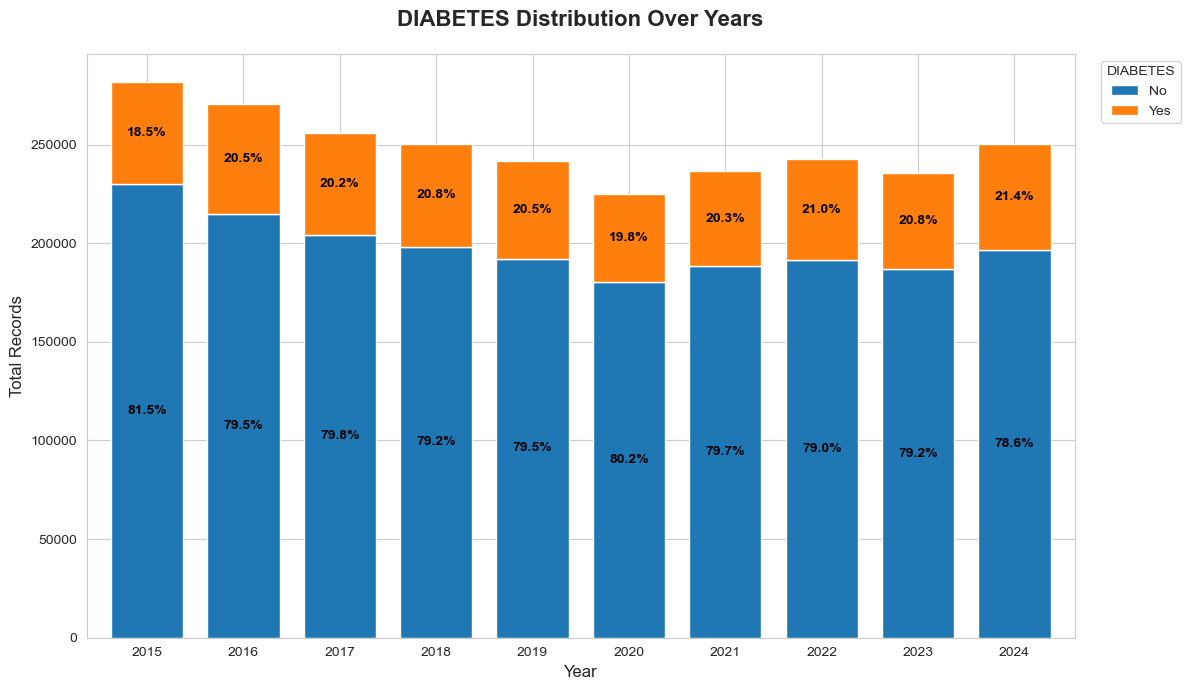

In [50]:
plot_column_as_per_year(df_decoded, 'DIABETES')

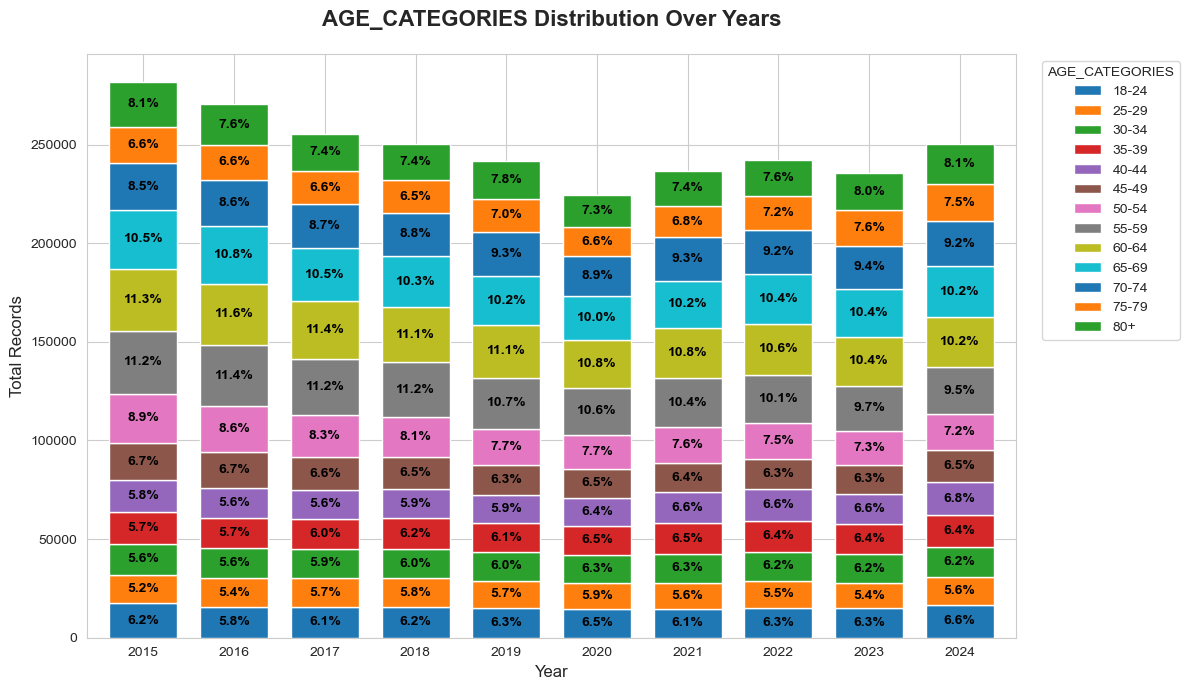

In [51]:
plot_column_as_per_year(df_decoded, 'AGE_CATEGORIES')